# 01 — Exploratory Data Analysis

**Dataset:** Twitter US Airline Sentiment (14,640 real tweets, Feb 2015)

Goal: Understand class distribution, feature characteristics, and data quality before modelling.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/Tweets.csv')
df['tweet_created'] = pd.to_datetime(df['tweet_created'], utc=True)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nNull counts:")
print(df.isnull().sum())

Shape: (14640, 15)

Columns: ['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']

Null counts:
tweet_id                            0
airline_sentiment                   0
airline_sentiment_confidence        0
negativereason                   5462
negativereason_confidence        4118
airline                             0
airline_sentiment_gold          14600
name                                0
negativereason_gold             14608
retweet_count                       0
text                                0
tweet_coord                     13621
tweet_created                       0
tweet_location                   4733
user_timezone                    4820
dtype: int64


## 1.1 Sentiment Distribution

Note the heavy class imbalance — **negative tweets dominate at 63%**. This is realistic for airline complaints on Twitter.

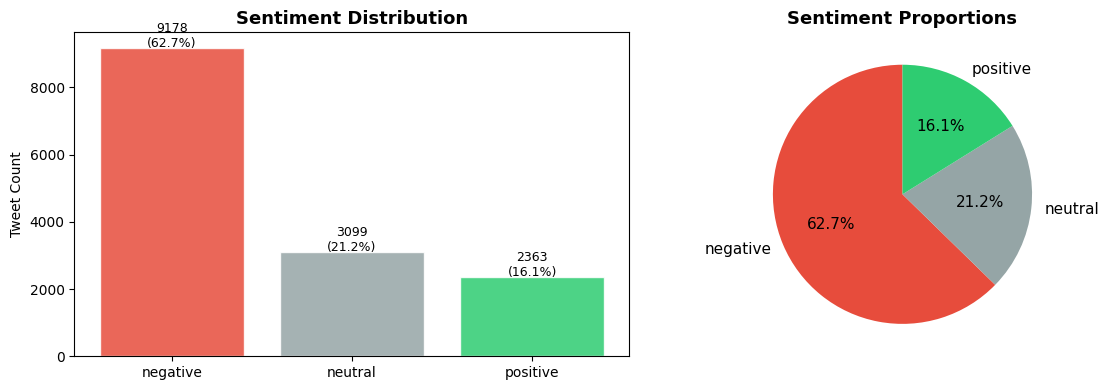

Majority class baseline (predict Negative always): 0.6269


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['airline_sentiment'].value_counts()
colors = {'negative': '#e74c3c', 'neutral': '#95a5a6', 'positive': '#2ecc71'}
color_list = [colors[c] for c in counts.index]

axes[0].bar(counts.index, counts.values, color=color_list, alpha=0.85, edgecolor='white')
axes[0].set_title('Sentiment Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Tweet Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=color_list, startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Sentiment Proportions', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/01_sentiment_dist.png', dpi=150, bbox_inches='tight')
plt.show()
print("Majority class baseline (predict Negative always):", round(counts['negative']/len(df), 4))

## 1.2 Sentiment by Airline

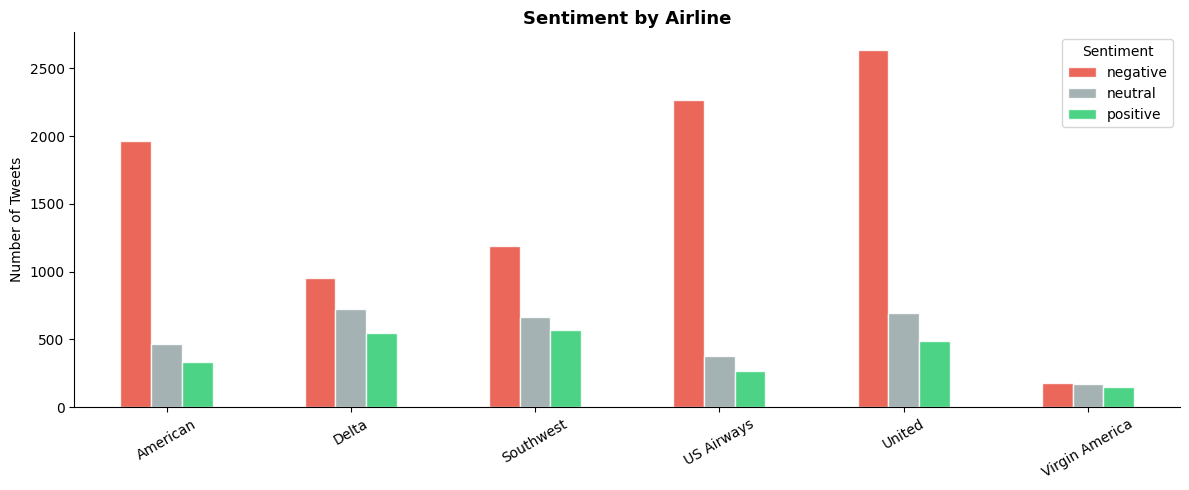

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))

ct = pd.crosstab(df['airline'], df['airline_sentiment'])
ct = ct[['negative', 'neutral', 'positive']]
ct.plot(kind='bar', ax=ax,
        color=['#e74c3c', '#95a5a6', '#2ecc71'], alpha=0.85,
        edgecolor='white', rot=30)

ax.set_title('Sentiment by Airline', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Tweets')
ax.set_xlabel('')
ax.legend(title='Sentiment', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../results/01_sentiment_by_airline.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.3 Top Negative Reasons

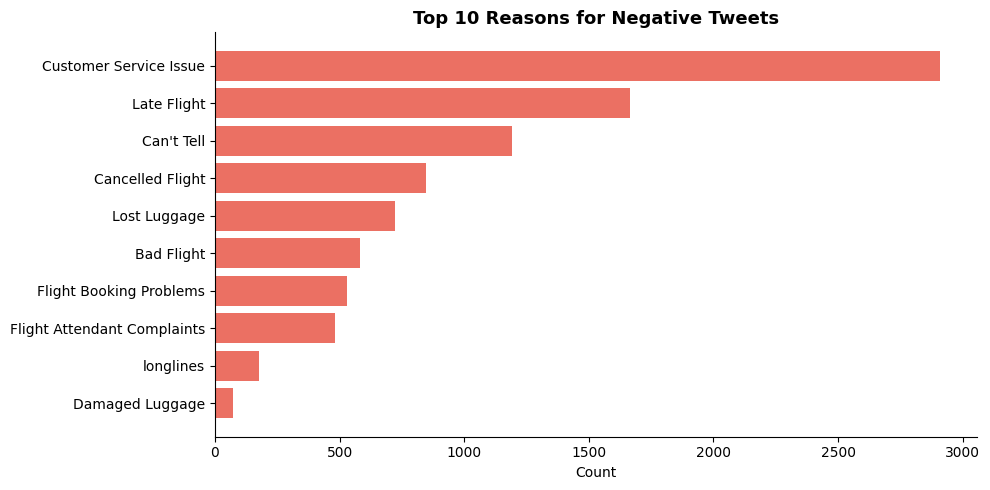

In [4]:
reason_counts = df['negativereason'].dropna().value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(reason_counts.index[::-1], reason_counts.values[::-1],
        color='#e74c3c', alpha=0.8)
ax.set_title('Top 10 Reasons for Negative Tweets', fontsize=13, fontweight='bold')
ax.set_xlabel('Count')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../results/01_negative_reasons.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.4 Tweet Volume Over Time

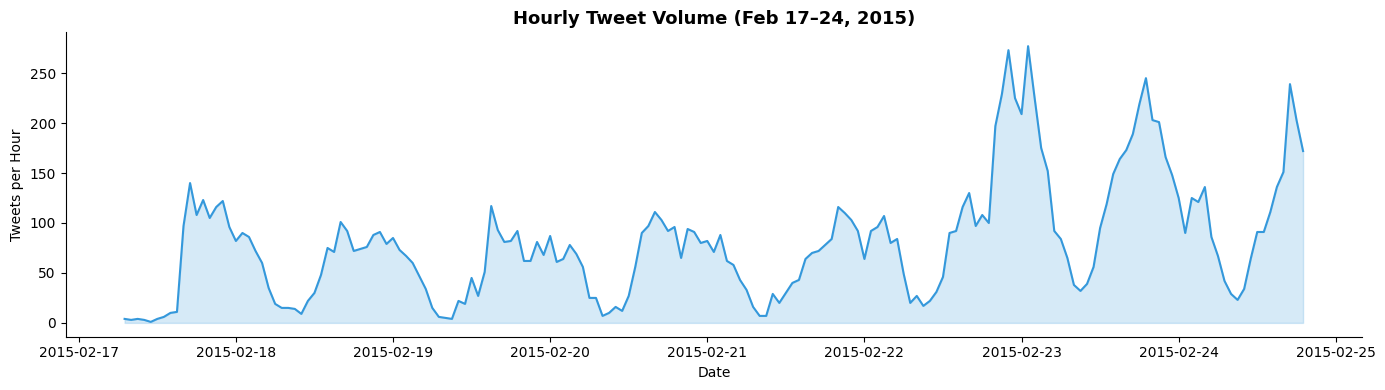

Total hourly time points: 181 — suitable for Prophet forecasting


In [5]:
hourly = df.groupby(df['tweet_created'].dt.floor('h')).size().reset_index()
hourly.columns = ['hour', 'count']
hourly['hour'] = hourly['hour'].dt.tz_localize(None)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(hourly['hour'], hourly['count'], color='#3498db', linewidth=1.5)
ax.fill_between(hourly['hour'], hourly['count'], alpha=0.2, color='#3498db')
ax.set_title('Hourly Tweet Volume (Feb 17–24, 2015)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Tweets per Hour')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('../results/01_tweet_volume.png', dpi=150, bbox_inches='tight')
plt.show()
print("Total hourly time points:", len(hourly), "— suitable for Prophet forecasting")

## 1.5 Text Statistics

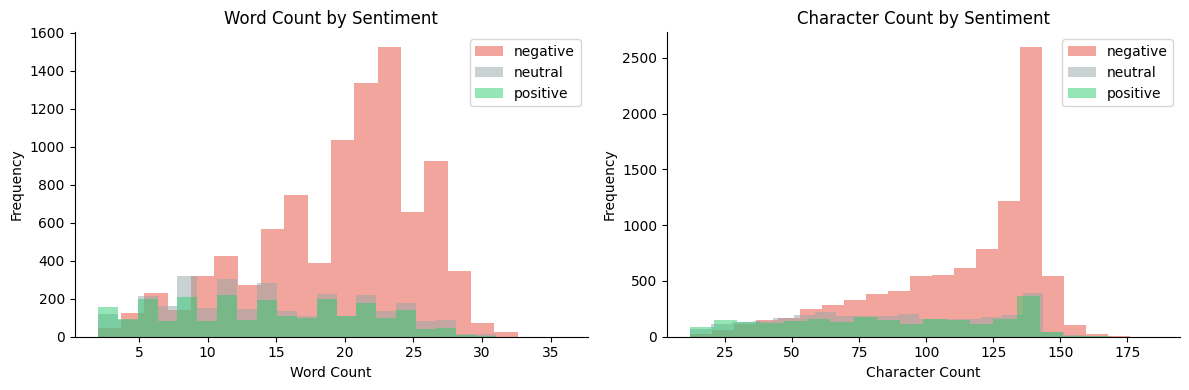

                   word_count  char_count
airline_sentiment                        
negative                 19.7       113.9
neutral                  14.4        87.4
positive                 14.0        86.1


In [6]:
df['word_count'] = df['text'].str.split().str.len()
df['char_count']  = df['text'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, label in zip(axes, ['word_count', 'char_count'], ['Word Count', 'Character Count']):
    for sent, color in [('negative','#e74c3c'), ('neutral','#95a5a6'), ('positive','#2ecc71')]:
        ax.hist(df[df['airline_sentiment']==sent][col], bins=20, alpha=0.5,
                label=sent, color=color)
    ax.set_xlabel(label)
    ax.set_ylabel('Frequency')
    ax.set_title(f'{label} by Sentiment')
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../results/01_text_stats.png', dpi=150, bbox_inches='tight')
plt.show()

print(df.groupby('airline_sentiment')[['word_count','char_count']].mean().round(1))

## 1.6 EDA Summary

- **14,640 real tweets** across 6 airlines, Feb 17–24 2015
- **Heavy class imbalance**: Negative 63%, Neutral 21%, Positive 16%
- Majority class baseline = **62.7%** — our models must beat this
- **181 hourly time points** available for forecasting
- US Airways and United dominate complaint volume
- 'Customer Service Issue' is the most cited negative reason